# Volatility-Adjusted Momentum — 12M — Equal Weight

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('vol_adjusted', '12M', 'equal_weight')

## 1. Signal and portfolio rule

Score = formation-period price return / annualized sample standard deviation of daily log returns. Annualization uses √252. The signal rewards stronger returns per unit of realized variability; it does not set inverse-volatility portfolio weights.

Each selected stock targets 1/N of pre-trade equity at a scheduled rebalance. If K<N qualify, target cash is (N−K)/N before charges; eligible stocks are not enlarged to 1/K. Sales precede purchases, which are reduced proportionally if charges or unfilled sales restrict available cash. Actual weights can therefore differ slightly from targets. Membership is rebuilt from current ranks without a retention buffer.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Return / volatility,MDTV (INR)
NSE:CUPID-EQ,11.545,"2,261,224,535.95"
NSE:SBC-EQ,5.605,"370,044,564.64"
NSE:ATHERENERG-EQ,5.211,"2,745,338,022.88"
NSE:RPTECH-EQ,4.773,"78,147,051.55"
NSE:SANSERA-EQ,3.834,"511,549,310.60"
NSE:LAURUSLABS-EQ,3.659,"2,123,882,567.10"
NSE:HFCL-EQ,3.254,"3,688,024,397.99"
NSE:KMEW-EQ,3.210,"175,654,741.20"
NSE:SILVERTUC-EQ,3.098,"65,229,764.81"
NSE:ACUTAAS-EQ,3.094,"1,065,873,412.85"


Symbol,Leg,Actual weight,Current selection,Execution status,Return / volatility,MDTV (INR)
NSE:CUPID-EQ,long,4.2%,True,selected,11.545,"2,261,224,535.95"
NSE:SBC-EQ,long,4.2%,True,selected,5.605,"370,044,564.64"
NSE:ATHERENERG-EQ,long,3.9%,True,selected,5.211,"2,745,338,022.88"
NSE:RPTECH-EQ,long,3.2%,True,selected,4.773,"78,147,051.55"
NSE:SANSERA-EQ,long,4.1%,True,selected,3.834,"511,549,310.60"
NSE:LAURUSLABS-EQ,long,4.2%,True,selected,3.659,"2,123,882,567.10"
NSE:HFCL-EQ,long,3.1%,True,selected,3.254,"3,688,024,397.99"
NSE:KMEW-EQ,long,3.2%,True,selected,3.210,"175,654,741.20"
NSE:SILVERTUC-EQ,long,3.3%,True,selected,3.098,"65,229,764.81"
NSE:ACUTAAS-EQ,long,3.1%,True,selected,3.094,"1,065,873,412.85"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:CUPID-EQ,2025-07-31,30.18,2026-07-31,230.62,664.2%


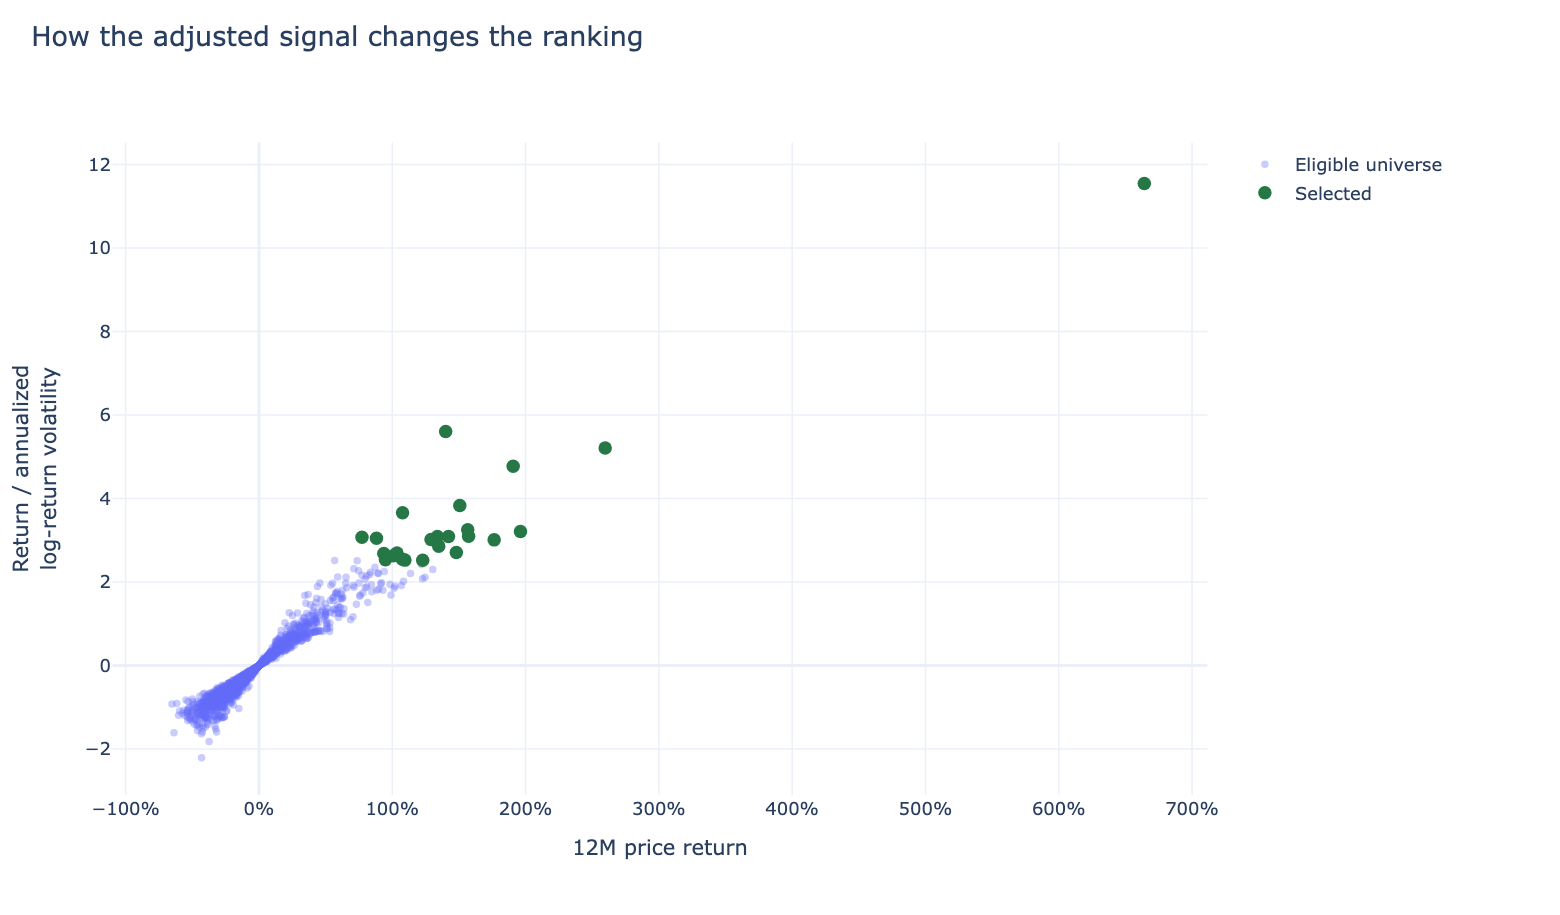

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,17.8%,16.6%,14.7%
1M,24,16.3%,15.2%,13.4%
1M,50,18.7%,17.7%,15.9%
3M,12,15.6%,15.0%,13.0%
3M,24,15.0%,14.4%,12.9%
3M,50,14.8%,14.2%,12.9%
6M,12,10.6%,10.2%,8.8%
6M,24,11.9%,11.5%,10.2%
6M,50,11.6%,11.2%,10.3%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,14.7%,0.410,-67.9%,11.2%
1M,24,13.4%,0.384,-71.1%,10.1%
1M,50,15.9%,0.520,-70.0%,9.0%
3M,12,13.0%,0.353,-71.7%,11.2%
3M,24,12.9%,0.360,-71.7%,9.2%
3M,50,12.9%,0.379,-70.1%,8.9%
6M,12,8.8%,0.180,-69.5%,10.7%
6M,24,10.2%,0.244,-71.5%,9.3%
6M,50,10.3%,0.252,-72.9%,9.1%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,16.6%,94.1%,1726
1M,24,16.3%,93.1%,1647
1M,50,15.6%,91.0%,1612
3M,12,17.8%,94.2%,1597
3M,24,16.3%,93.3%,1582
3M,50,15.4%,92.0%,1601
6M,12,17.4%,95.5%,2386
6M,24,16.9%,94.5%,1639
6M,50,16.0%,93.2%,1639


### CAGR

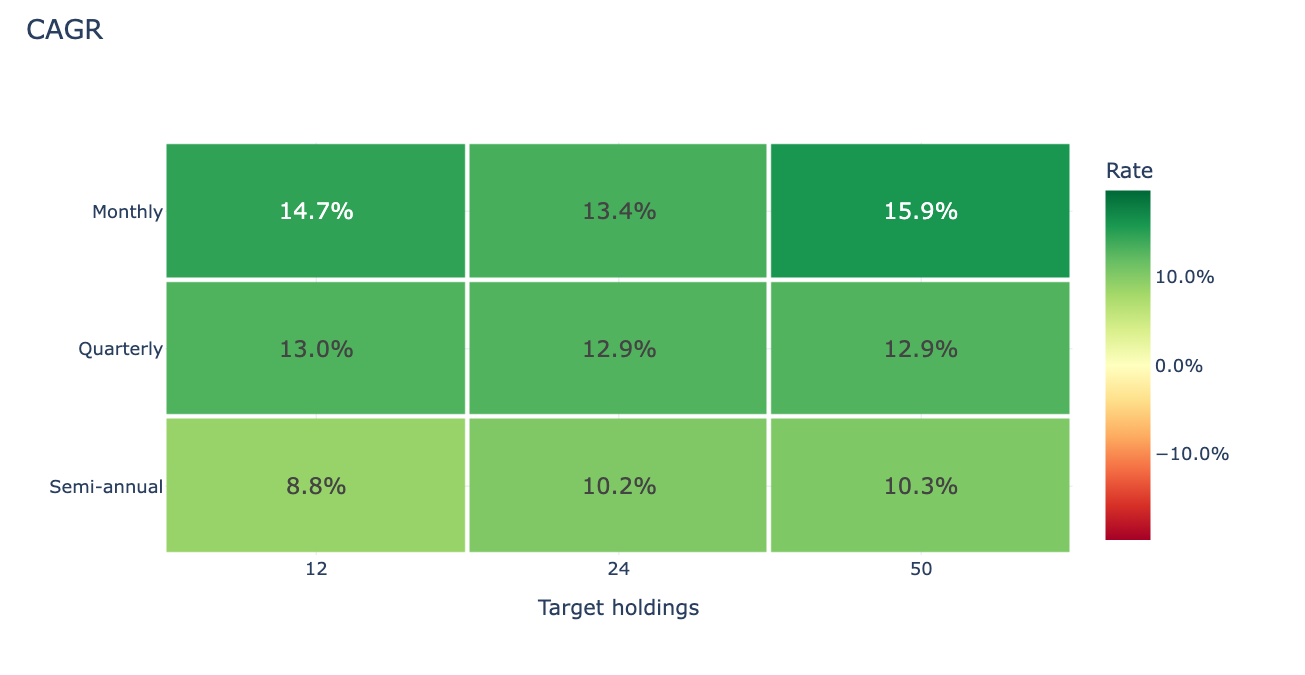

In [5]:
research.heatmap('cagr')

### Sharpe ratio

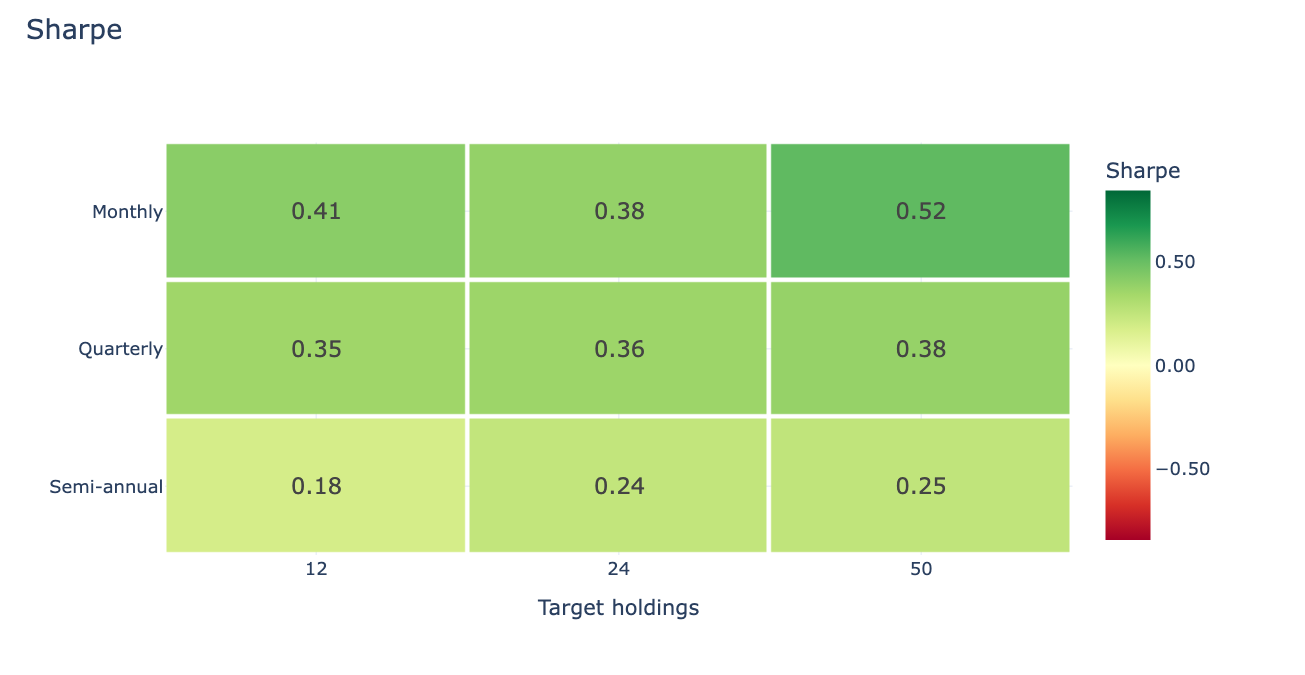

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

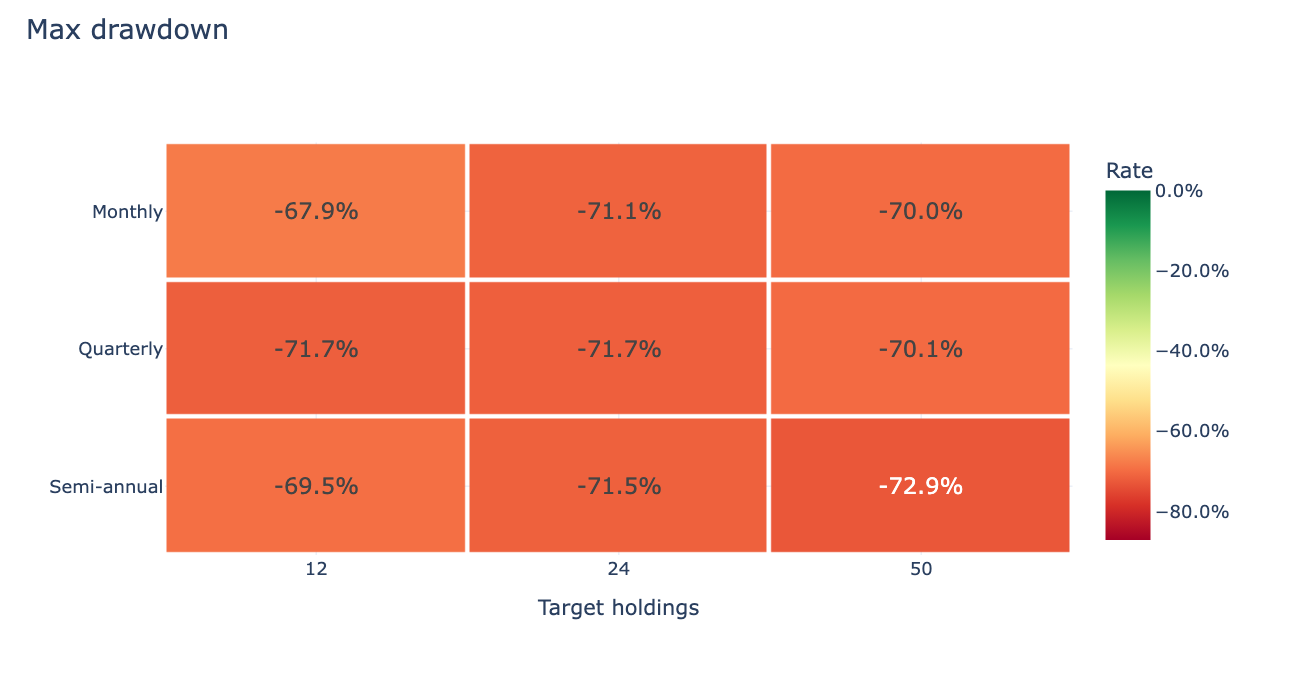

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

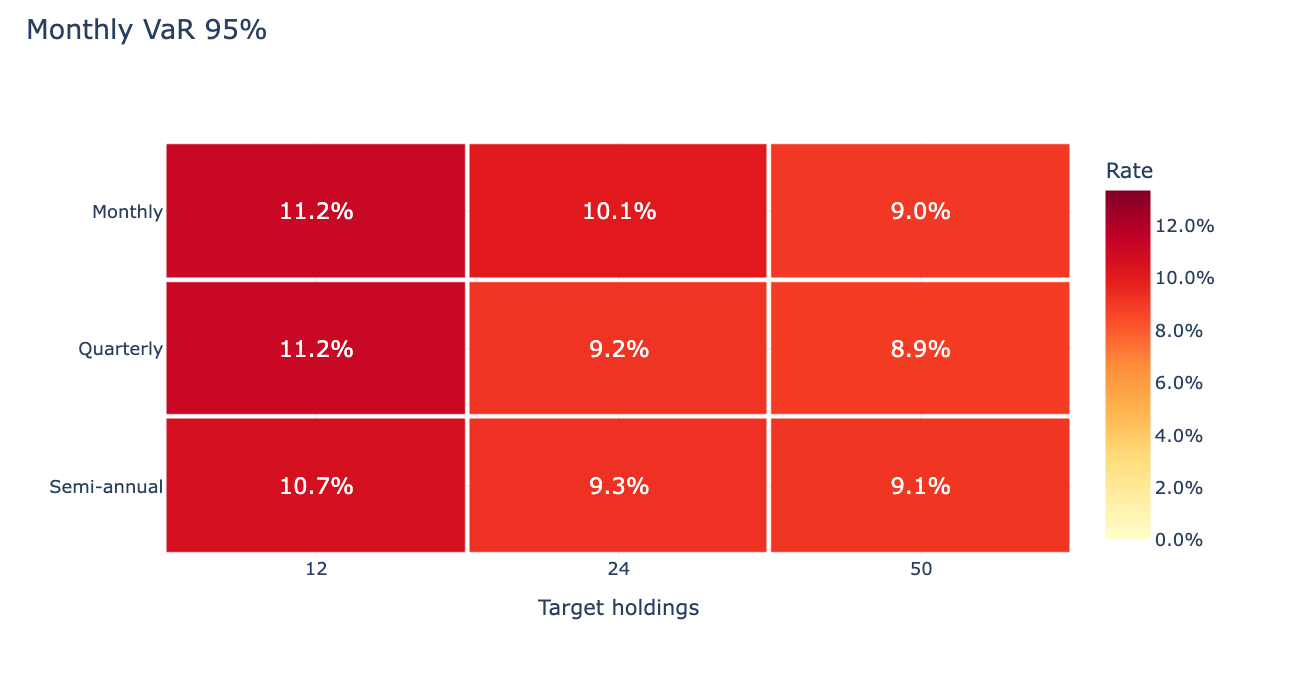

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

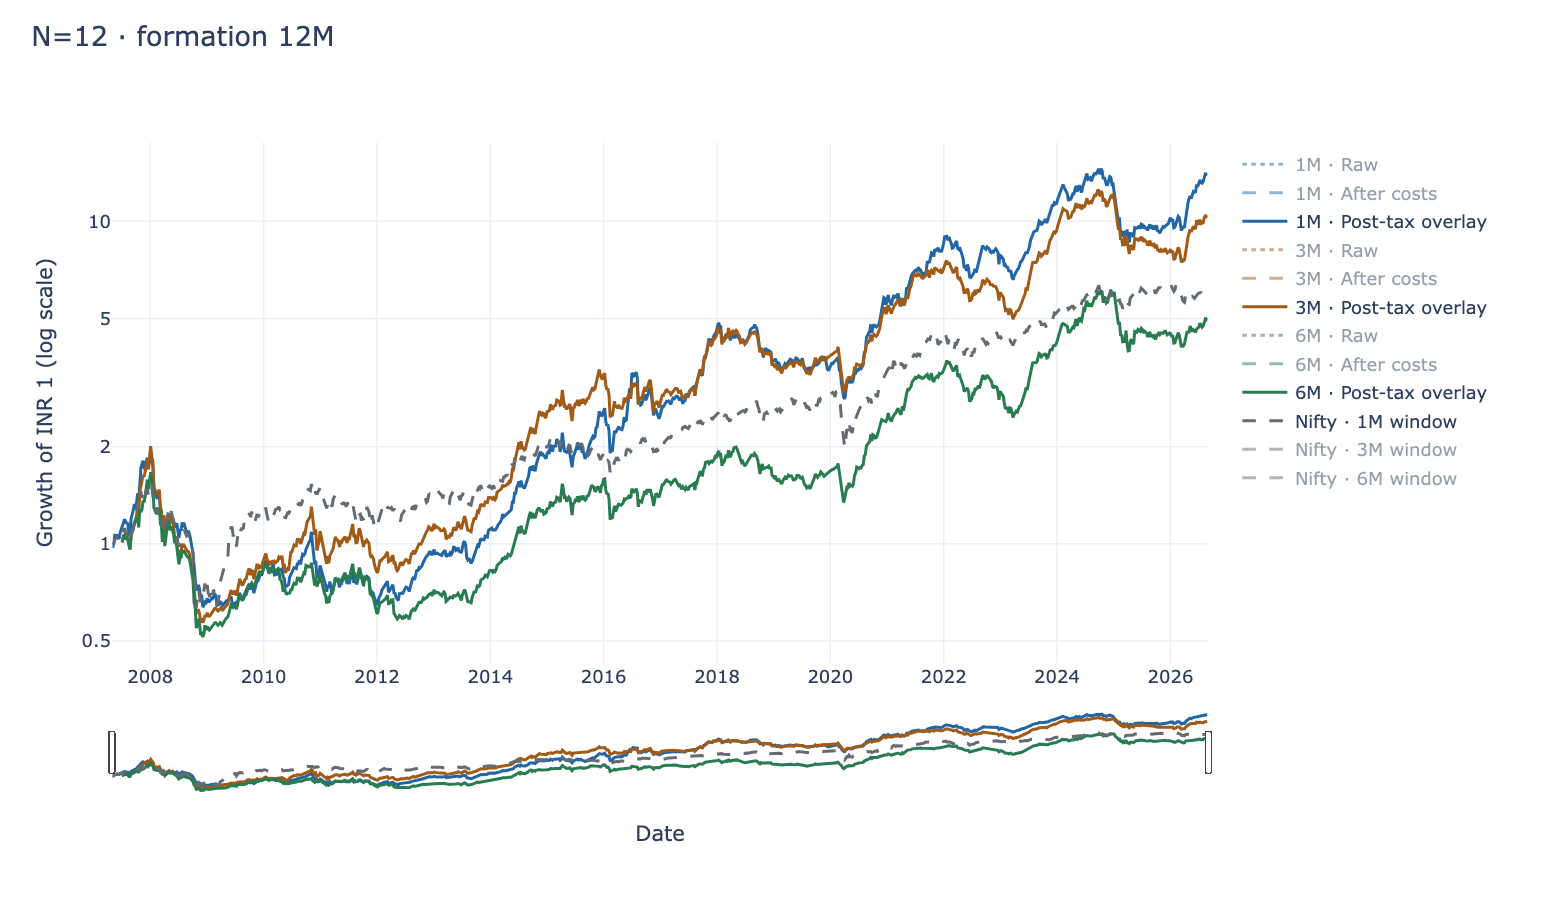

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,17.8%,0.529,-66.3%,11.1%
1M,After costs,16.6%,0.484,-66.9%,11.2%
1M,Post-tax overlay,14.7%,0.410,-67.9%,11.2%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,15.6%,0.456,-70.4%,11.2%
3M,After costs,15.0%,0.431,-70.6%,11.2%
3M,Post-tax overlay,13.0%,0.353,-71.7%,11.2%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,10.6%,0.261,-68.0%,10.7%
6M,After costs,10.2%,0.244,-68.1%,10.7%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,16.4%,93.1%,1654
1M,After costs,16.4%,93.4%,1685
3M,Raw,17.5%,93.4%,1583
3M,After costs,17.5%,93.6%,1593
6M,Raw,17.0%,94.9%,1965
6M,After costs,17.0%,95.1%,1968
1M,Post-tax overlay,16.6%,94.1%,1726
3M,Post-tax overlay,17.8%,94.2%,1597
6M,Post-tax overlay,17.4%,95.5%,2386
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

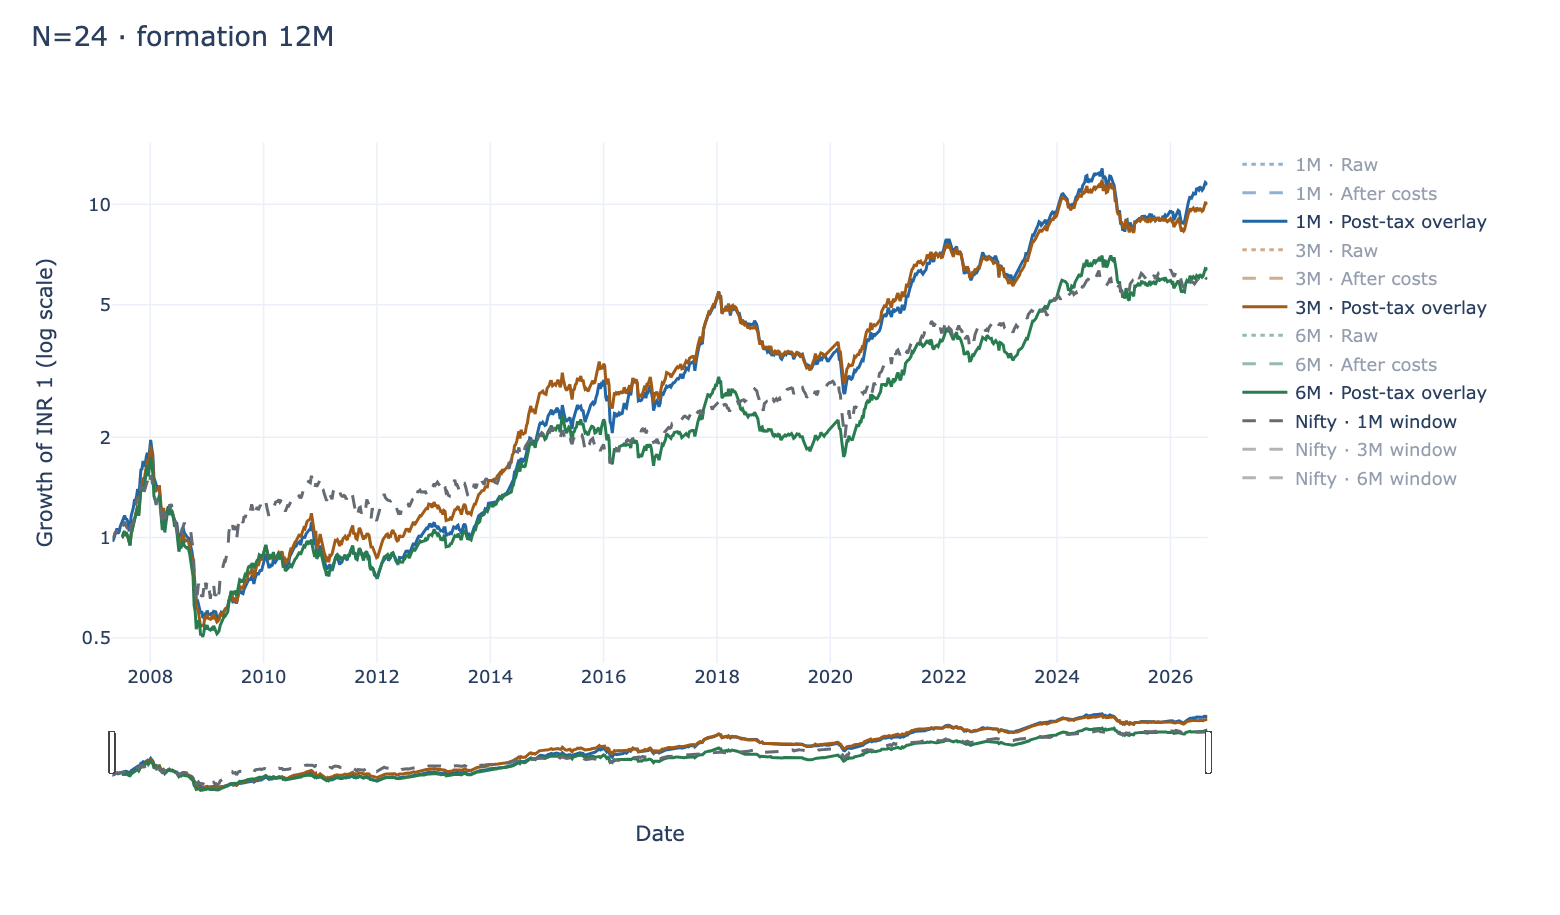

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,16.3%,0.505,-70.1%,10.1%
1M,After costs,15.2%,0.459,-70.4%,10.1%
1M,Post-tax overlay,13.4%,0.384,-71.1%,10.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,15.0%,0.456,-70.4%,9.2%
3M,After costs,14.4%,0.430,-70.5%,9.2%
3M,Post-tax overlay,12.9%,0.360,-71.7%,9.2%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,11.9%,0.322,-70.1%,9.3%
6M,After costs,11.5%,0.304,-70.2%,9.3%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,16.1%,92.1%,1635
1M,After costs,16.1%,92.5%,1644
3M,Raw,16.0%,92.5%,1570
3M,After costs,16.0%,92.7%,1579
6M,Raw,16.6%,93.9%,1599
6M,After costs,16.6%,94.0%,1610
1M,Post-tax overlay,16.3%,93.1%,1647
3M,Post-tax overlay,16.3%,93.3%,1582
6M,Post-tax overlay,16.9%,94.5%,1639
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

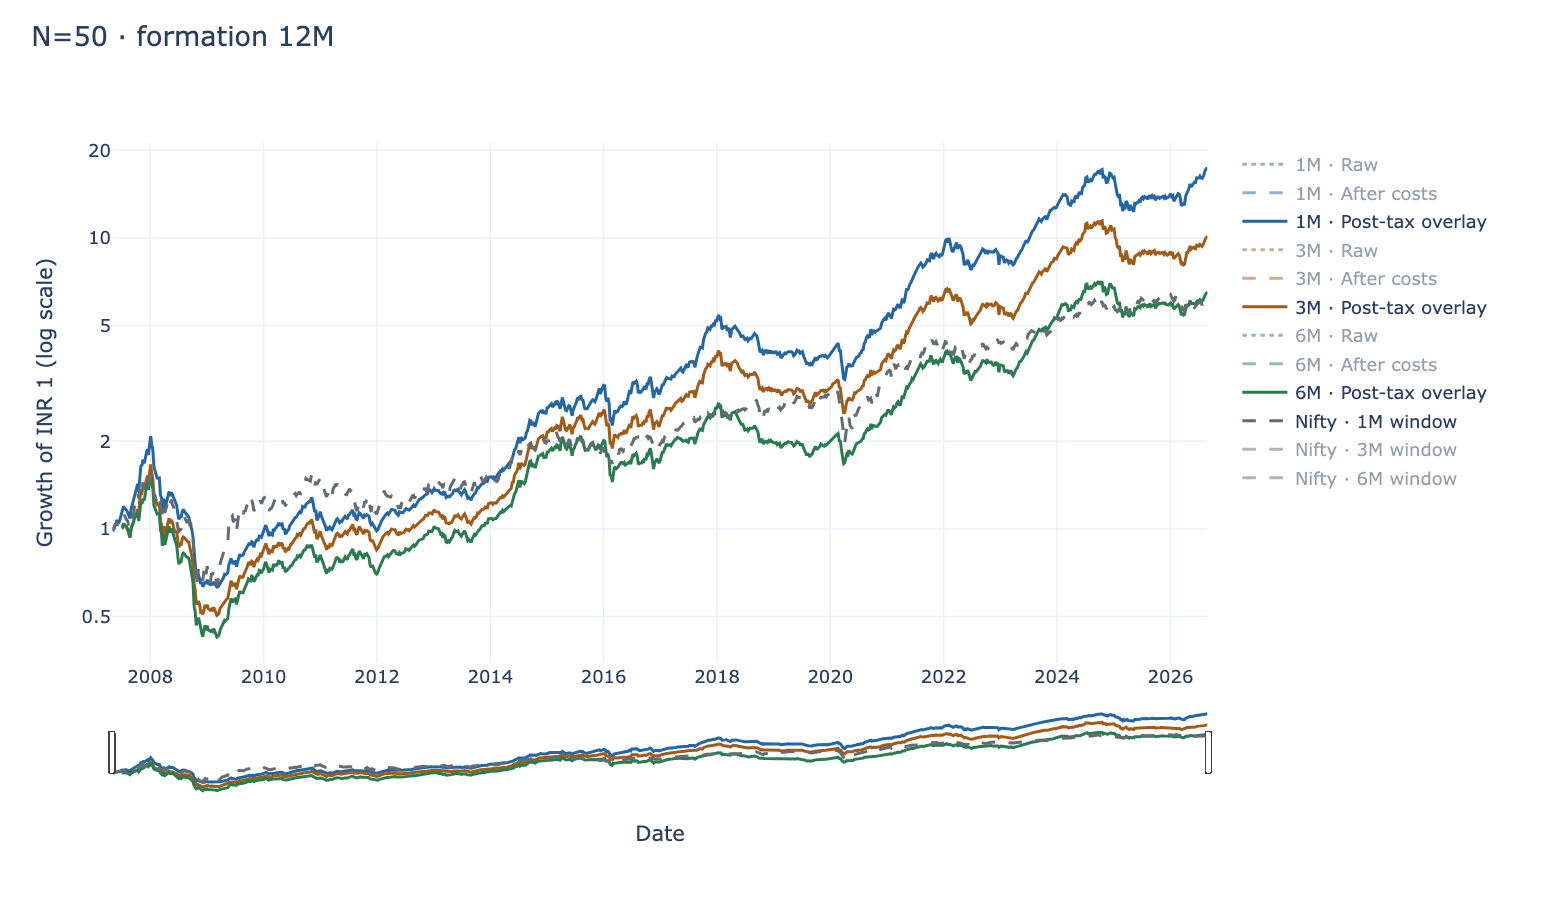

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,18.7%,0.652,-68.7%,9.0%
1M,After costs,17.7%,0.606,-69.0%,9.0%
1M,Post-tax overlay,15.9%,0.520,-70.0%,9.0%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,14.8%,0.476,-68.9%,8.8%
3M,After costs,14.2%,0.448,-69.1%,8.9%
3M,Post-tax overlay,12.9%,0.379,-70.1%,8.9%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,11.6%,0.321,-71.7%,9.1%
6M,After costs,11.2%,0.301,-71.8%,9.1%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,15.4%,89.6%,1585
1M,After costs,15.4%,90.1%,1599
3M,Raw,15.2%,91.0%,1588
3M,After costs,15.2%,91.4%,1597
6M,Raw,15.7%,92.6%,1600
6M,After costs,15.7%,92.7%,1631
1M,Post-tax overlay,15.6%,91.0%,1612
3M,Post-tax overlay,15.4%,92.0%,1601
6M,Post-tax overlay,16.0%,93.2%,1639
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2008-01-07,2009-03-12,2014-09-11,1647,2438,-71.1%
3M,2008-01-07,2008-11-20,2014-06-09,1582,2344,-71.7%
6M,2008-01-07,2008-12-02,2014-09-01,1639,2428,-71.5%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,15.34,0.8%,68.7%
1M,24,31.35,0.7%,72.2%
1M,50,72.39,0.4%,78.2%
3M,12,15.60,1.3%,49.1%
3M,24,31.91,1.1%,53.6%
3M,50,73.51,0.8%,62.8%
6M,12,16.79,1.3%,37.9%
6M,24,32.10,0.7%,38.6%
6M,50,66.44,0.8%,43.6%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,32.2%,"8,678,553.83",0
1M,24,28.0%,"7,279,894.73",0
1M,50,22.9%,"8,240,606.46",0
3M,12,52.7%,"4,413,188.59",0
3M,24,47.5%,"3,957,834.01",0
3M,50,40.0%,"3,137,704.32",0
6M,12,65.5%,"1,441,653.72",0
6M,24,63.6%,"1,666,901.38",0
6M,50,56.4%,"1,442,824.64",0


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

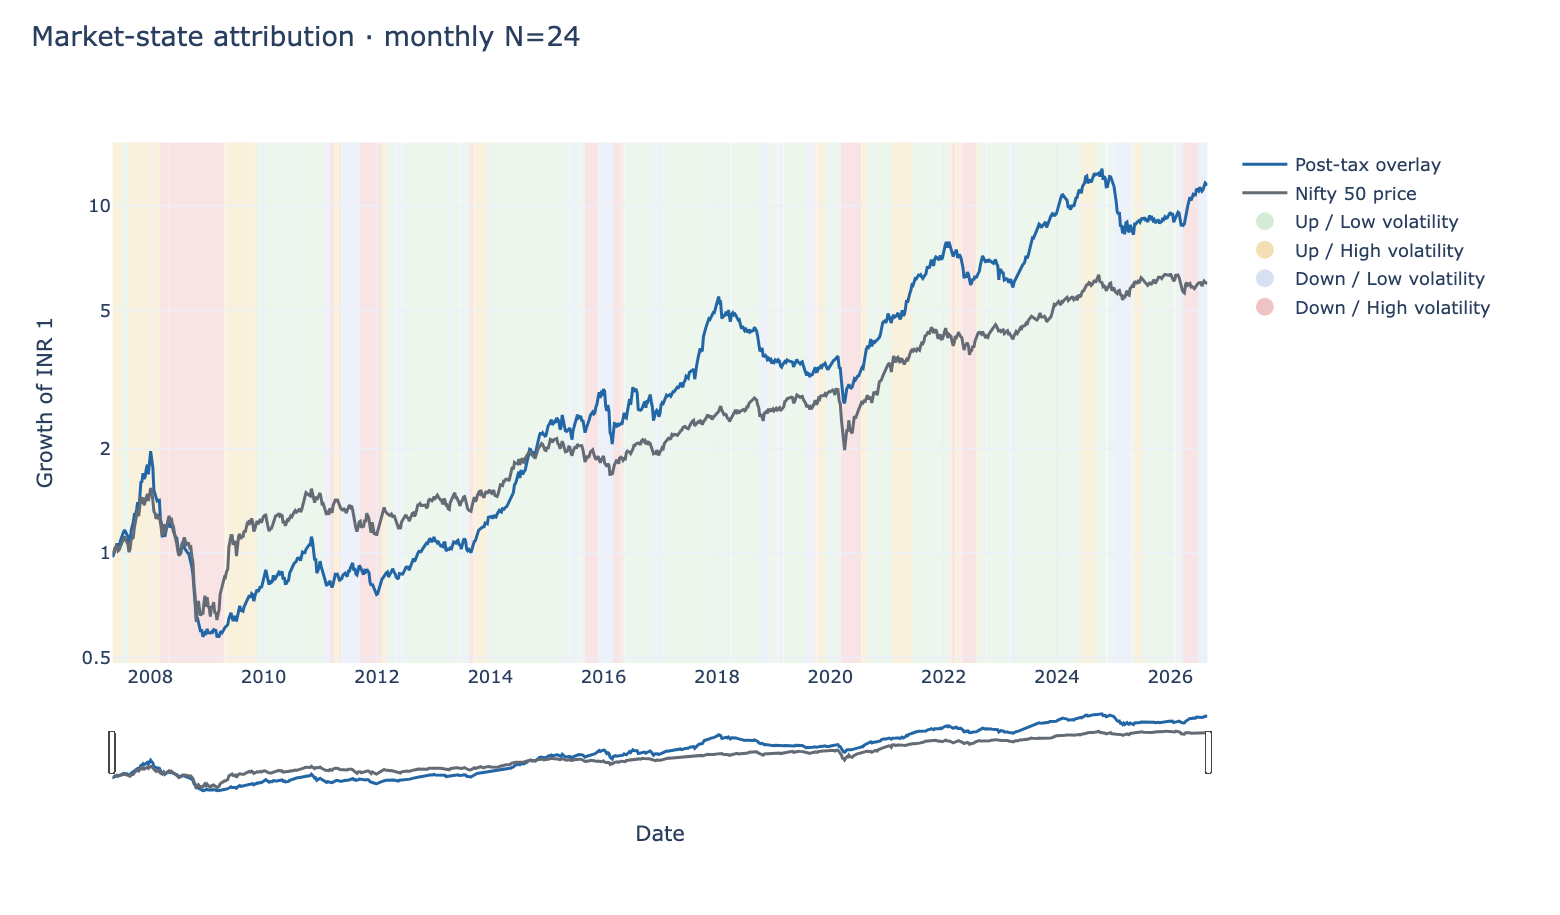

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.03%,1.42%,54.14%
Down / Low volatility,609,-0.02%,1.54%,53.53%
Up / High volatility,720,0.20%,1.52%,62.36%
Up / Low volatility,2694,0.07%,1.17%,57.50%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,3560
1M,24,2007-05-03,2026-08-03,232,7273
1M,50,2007-05-03,2026-08-03,232,16794
3M,12,2007-07-02,2026-07-01,77,1201
3M,24,2007-07-02,2026-07-01,77,2457
3M,50,2007-07-02,2026-07-01,77,5660
6M,12,2007-07-02,2026-07-01,39,655
6M,24,2007-07-02,2026-07-01,39,1252
6M,50,2007-07-02,2026-07-01,39,2591


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 12M — Equal Weight](04_raw_momentum_12m_equal_weight.ipynb). The comparison holds formation, maintenance, frequency and N fixed.